In [57]:
import pandas as pd  # tables
import numpy as np  # math
import matplotlib.pyplot as plt  # charts
import seaborn as sns  # fabcharts

from sklearn import tree  # python.library
from sklearn.tree import DecisionTreeClassifier

# 1.Sunburn

In [58]:
# Create dataset

data = pd.DataFrame({
    "Name": ["Sarah", "Dana", "Alex", "Annie", "Emily", "Pete", "John", "Katie"],
    "Hair": ["blonde", "blonde", "brown", "blonde", "red", "brown", "brown", "brown"],
    "Height": ["average", "tall", "short", "short", "average", "tall", "average", "short"],
    "Build": ["light", "average", "average", "average", "heavy", "heavy", "heavy", "light"],
    "Lotion": ["no", "yes", "yes", "no", "no", "no", "no", "yes"],
    "Result": ["sunburned", "none", "none", "sunburned", "sunburned", "none", "none", "none"]
})

data

,Name,Hair,Height,Build,Lotion,Result
0,Sarah,blonde,average,light,no,sunburned
1,Dana,blonde,tall,average,yes,none
2,Alex,brown,short,average,yes,none
3,Annie,blonde,short,average,no,sunburned
4,Emily,red,average,heavy,no,sunburned
5,Pete,brown,tall,heavy,no,none
6,John,brown,average,heavy,no,none
7,Katie,brown,short,light,yes,none


**Task 1, Part A:** Sunburn entropy is **≈ 0.95 bits**

In [59]:
# Import the entropy function from the SciPy library
from scipy.stats import entropy

# Import the IG function from the SciPy library
def information_gain(df, feature, target):
    H_before = dataset_entropy(df, target)

    weighted_entropy = 0
    for value in df[feature].unique():
        subset = df[df[feature] == value]
        weight = len(subset) / len(df)
        weighted_entropy += weight * dataset_entropy(subset, target)

    IG = H_before - weighted_entropy
    return H_before, weighted_entropy, IG

# Target labels
y = data["Result"].values

# Class probabilities
counts = pd.Series(y).value_counts()
p = counts / counts.sum()

# Entropy in bits (log base 2)
H = entropy(p, base=2)

print("Class counts:\n", counts)
print("\nProbabilities:\n", p)
print(f"\nEntropy(Result) = {H:.4f} bits")

Class counts:
 none         5
sunburned    3
Name: count, dtype: int64

Probabilities:
 none         0.625
sunburned    0.375
Name: count, dtype: float64

Entropy(Result) = 0.9544 bits


**Task 1, Part B:** The root feature is **Hair**, as it has the highest Information Gain (**IG ≈ 0.61**). The next nodes are: Lotion → Height → Build.

In [60]:
# Information Gain for ALL features + show the best (root) feature

features = ["Hair", "Height", "Build", "Lotion"]

results = []
for f in features:
    H_before, H_after, IG = information_gain(data, f, "Result")
    results.append([f, H_before, H_after, IG])

ig_df = pd.DataFrame(results, columns=["Feature", "H_before", "H_after", "IG"]).sort_values("IG", ascending=False)

print(ig_df)
print("\nRoot feature =", ig_df.iloc[0]["Feature"])

  Feature  H_before   H_after        IG
0    Hair  0.954434  0.344361  0.610073
3  Lotion  0.954434  0.606844  0.347590
1  Height  0.954434  0.688722  0.265712
2   Build  0.954434  0.938722  0.015712

Root feature = Hair


**Task 1, Part C:** For a new instance with [Hair = blonde, Height = average, and Lotion = no], the predicted class is **sunburned**.


In [61]:
# Encode categorical features into numeric format
from sklearn.preprocessing import OneHotEncoder

# 1) Train X/y
X = data[["Hair", "Height", "Build", "Lotion"]]
y = data["Result"]

enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_enc = enc.fit_transform(X)

clf = DecisionTreeClassifier(criterion="entropy", random_state=42)
clf.fit(X_enc, y)

# 2) Predict for example X
X_new = pd.DataFrame([{
    "Hair": "blonde",
    "Height": "average",
    "Build": "heavy",
    "Lotion": "no"
}])

X_new_enc = enc.transform(X_new)
pred = clf.predict(X_new_enc)[0]
print("Predicted class:", pred)

Predicted class: sunburned


# 2.Credit risk

In [62]:
# Create Credit Risk dataset
CreditRisk = pd.DataFrame({
    "Credit_History": [
        "bad","bad","bad","unknown","unknown","good",
        "bad","unknown","good","unknown","unknown","good","good","good"
    ],
    "Debt": [
        "low","high","low","high","high","high",
        "low","low","high","low","low","low","high","high"
    ],
    "Income": [
        "0to30","30to60","0to30","30to60","0to30","0to30",
        "over60","30to60","30to60","over60","over60","over60","over60","over60"
    ],
    "Risk": [
        "high","high","high","high","high","high",
        "medium","medium","medium","low","low","low","low","low"
    ]
})

CreditRisk

,Credit_History,Debt,Income,Risk
0,bad,low,0to30,high
1,bad,high,30to60,high
2,bad,low,0to30,high
3,unknown,high,30to60,high
4,unknown,high,0to30,high
5,good,high,0to30,high
6,bad,low,over60,medium
7,unknown,low,30to60,medium
8,good,high,30to60,medium
9,unknown,low,over60,low


**Task 2, Part A:** The entropy of the Credit Risk dataset with respect to the target class label Risk is **1.53 bits**.

In [63]:
# Target labels
y = CreditRisk["Risk"].values

# Class probabilities
counts = pd.Series(y).value_counts()
p = counts / counts.sum()

# Entropy (log base 2 → bits)
H = entropy(p, base=2)

print("Class counts:\n", counts)
print("\nProbabilities:\n", p)
print(f"\nEntropy(Risk) = {H:.4f} bits")

Class counts:
 high      6
low       5
medium    3
Name: count, dtype: int64

Probabilities:
 high      0.428571
low       0.357143
medium    0.214286
Name: count, dtype: float64

Entropy(Risk) = 1.5306 bits


**Task 2, Part B:** The individual entropies are: Credit_History = **1.58 bits**, Debt = **1.00 bit**, and Income = **1.56 bits**.


In [64]:
features = ["Credit_History", "Debt", "Income"]

for f in features:
    counts = CreditRisk[f].value_counts()
    p = counts / counts.sum()
    H = entropy(p, base=2)

    print(f"\nFeature: {f}")
    print("Counts:\n", counts)
    print(f"Entropy = {H:.4f} bits")


Feature: Credit_History
Counts:
 Credit_History
unknown    5
good       5
bad        4
Name: count, dtype: int64
Entropy = 1.5774 bits

Feature: Debt
Counts:
 Debt
low     7
high    7
Name: count, dtype: int64
Entropy = 1.0000 bits

Feature: Income
Counts:
 Income
over60    6
0to30     4
30to60    4
Name: count, dtype: int64
Entropy = 1.5567 bits


**Task 2, Part C:** **Income** is selected by ID3 as the root feature because it has **the highest Information Gain (IG ≈ 0.97)**. Information Gain measures how much the uncertainty (entropy) of the target class Risk decreases after splitting the data on a feature.

Steps (shown in the calculations):

	1.	For each feature (Credit_History, Debt, Income), split the dataset into subsets by the feature’s values.

	2.	Compute the entropy of Risk within each subset.

	3.	Weight each subset entropy by the subset proportion (subset size / total size).

	4.	Sum these weighted entropies to get H_after for that feature.

	5.	Compute IG(feature) = H(Risk) − H_after(feature).

The feature with the largest IG produces the greatest reduction in entropy, so it is chosen as the root of the decision tree.

In [65]:
# Compute Information Gain for the Income feature

feature = "Income"
target = "Risk"

# ---------- Step 1: Entropy of target class (H_before) ----------
counts_total = CreditRisk[target].value_counts()
p_total = counts_total / counts_total.sum()
H_before = entropy(p_total, base=2)

print("STEP 1) Target class counts:", counts_total.to_dict())
print("STEP 1) H_before (Entropy of Risk) =", round(H_before, 6), "bits\n")


# ---------- Step 2: Split dataset by feature and compute subset entropies ----------
subsets = {val: CreditRisk[CreditRisk[feature] == val] for val in CreditRisk[feature].unique()}

subset_entropies = {}
for val, sub in subsets.items():
    counts_sub = sub[target].value_counts()
    p_sub = counts_sub / counts_sub.sum()
    H_sub = entropy(p_sub, base=2)
    subset_entropies[val] = H_sub

print("STEP 2) Subset entropies H(Risk | Income=value):")
for val, H_sub in subset_entropies.items():
    print(f"  {val}: {round(H_sub, 6)}")
print()


# ---------- Step 3: Compute weights for each subset ----------
N = len(CreditRisk)
weights = {val: len(subsets[val]) / N for val in subsets}

print("STEP 3) Subset weights (subset size / total size):")
for val, w in weights.items():
    print(f"  {val}: {round(w, 6)}")
print()


# ---------- Step 4: Weighted average entropy after split (H_after) ----------
weighted_terms = {val: weights[val] * subset_entropies[val] for val in subsets}
H_after = sum(weighted_terms.values())

print("STEP 4) Weighted entropy terms w * H(subset):")
for val, term in weighted_terms.items():
    print(f"  {val}: {round(term, 6)}")
print("STEP 4) H_after =", round(H_after, 6), "bits\n")


# ---------- Step 5: Information Gain ----------
IG = H_before - H_after
print("STEP 5) IG =", round(IG, 6))

STEP 1) Target class counts: {'high': 6, 'low': 5, 'medium': 3}
STEP 1) H_before (Entropy of Risk) = 1.530619 bits

STEP 2) Subset entropies H(Risk | Income=value):
  0to30: 0.0
  30to60: 1.0
  over60: 0.650022

STEP 3) Subset weights (subset size / total size):
  0to30: 0.285714
  30to60: 0.285714
  over60: 0.428571

STEP 4) Weighted entropy terms w * H(subset):
  0to30: 0.0
  30to60: 0.285714
  over60: 0.278581
STEP 4) H_after = 0.564295 bits

STEP 5) IG = 0.966324


In [66]:
# Compute Information Gain for the Credit_History feature

feature = "Credit_History"
target = "Risk"

# ---------- Step 1: Entropy of target class (H_before) ----------
counts_total = CreditRisk[target].value_counts()
p_total = counts_total / counts_total.sum()
H_before = entropy(p_total, base=2)

print("STEP 1) Target class counts:", counts_total.to_dict())
print("STEP 1) H_before (Entropy of Risk) =", round(H_before, 6), "bits\n")


# ---------- Step 2: Split dataset by feature and compute subset entropies ----------
subsets = {val: CreditRisk[CreditRisk[feature] == val] for val in CreditRisk[feature].unique()}

subset_entropies = {}
for val, sub in subsets.items():
    counts_sub = sub[target].value_counts()
    p_sub = counts_sub / counts_sub.sum()
    H_sub = entropy(p_sub, base=2)
    subset_entropies[val] = H_sub

print("STEP 2) Subset entropies H(Risk | Credit_History=value):")
for val, H_sub in subset_entropies.items():
    print(f"  {val}: {round(H_sub, 6)}")
print()


# ---------- Step 3: Compute weights for each subset ----------
N = len(CreditRisk)
weights = {val: len(subsets[val]) / N for val in subsets}

print("STEP 3) Subset weights (subset size / total size):")
for val, w in weights.items():
    print(f"  {val}: {round(w, 6)}")
print()


# ---------- Step 4: Weighted average entropy after split (H_after) ----------
weighted_terms = {val: weights[val] * subset_entropies[val] for val in subsets}
H_after = sum(weighted_terms.values())

print("STEP 4) Weighted entropy terms w * H(subset):")
for val, term in weighted_terms.items():
    print(f"  {val}: {round(term, 6)}")
print("STEP 4) H_after =", round(H_after, 6), "bits\n")


# ---------- Step 5: Information Gain ----------
IG = H_before - H_after
print("STEP 5) IG =", round(IG, 6))

STEP 1) Target class counts: {'high': 6, 'low': 5, 'medium': 3}
STEP 1) H_before (Entropy of Risk) = 1.530619 bits

STEP 2) Subset entropies H(Risk | Credit_History=value):
  bad: 0.811278
  unknown: 1.521928
  good: 1.370951

STEP 3) Subset weights (subset size / total size):
  bad: 0.285714
  unknown: 0.357143
  good: 0.357143

STEP 4) Weighted entropy terms w * H(subset):
  bad: 0.231794
  unknown: 0.543546
  good: 0.489625
STEP 4) H_after = 1.264965 bits

STEP 5) IG = 0.265654


In [67]:
# Compute Information Gain for the Debt feature

feature = "Debt"
target = "Risk"

# ---------- Step 1: Entropy of target class (H_before) ----------
counts_total = CreditRisk[target].value_counts()
p_total = counts_total / counts_total.sum()
H_before = entropy(p_total, base=2)

print("STEP 1) Target class counts:", counts_total.to_dict())
print("STEP 1) H_before (Entropy of Risk) =", round(H_before, 6), "bits\n")


# ---------- Step 2: Split dataset by feature and compute subset entropies ----------
subsets = {val: CreditRisk[CreditRisk[feature] == val] for val in CreditRisk[feature].unique()}

subset_entropies = {}
for val, sub in subsets.items():
    counts_sub = sub[target].value_counts()
    p_sub = counts_sub / counts_sub.sum()
    H_sub = entropy(p_sub, base=2)
    subset_entropies[val] = H_sub

print("STEP 2) Subset entropies H(Risk | Debt=value):")
for val, H_sub in subset_entropies.items():
    print(f"  {val}: {round(H_sub, 6)}")
print()


# ---------- Step 3: Compute weights for each subset ----------
N = len(CreditRisk)
weights = {val: len(subsets[val]) / N for val in subsets}

print("STEP 3) Subset weights (subset size / total size):")
for val, w in weights.items():
    print(f"  {val}: {round(w, 6)}")
print()


# ---------- Step 4: Weighted average entropy after split (H_after) ----------
weighted_terms = {val: weights[val] * subset_entropies[val] for val in subsets}
H_after = sum(weighted_terms.values())

print("STEP 4) Weighted entropy terms w * H(subset):")
for val, term in weighted_terms.items():
    print(f"  {val}: {round(term, 6)}")
print("STEP 4) H_after =", round(H_after, 6), "bits\n")


# ---------- Step 5: Information Gain ----------
IG = H_before - H_after
print("STEP 5) IG =", round(IG, 6))

STEP 1) Target class counts: {'high': 6, 'low': 5, 'medium': 3}
STEP 1) H_before (Entropy of Risk) = 1.530619 bits

STEP 2) Subset entropies H(Risk | Debt=value):
  low: 1.556657
  high: 1.378783

STEP 3) Subset weights (subset size / total size):
  low: 0.5
  high: 0.5

STEP 4) Weighted entropy terms w * H(subset):
  low: 0.778328
  high: 0.689392
STEP 4) H_after = 1.46772 bits

STEP 5) IG = 0.062899


In [68]:
# SUMMARY: Compute Information Gain (IG) for each descriptive feature

features = ["Credit_History", "Debt", "Income"]

results = []
for f in features:
    H_before, H_after, IG = information_gain(CreditRisk, f, "Risk")
    results.append([f, H_before, H_after, IG])

ig_df = pd.DataFrame(results, columns=["Feature", "H_before", "H_after", "IG"]).sort_values("IG", ascending=False)

ig_df


,Feature,H_before,H_after,IG
2,Income,1.530619,0.564295,0.966324
0,Credit_History,1.530619,1.264965,0.265654
1,Debt,1.530619,1.467720,0.062899


In [69]:
print("ID3 root feature =", ig_df.iloc[0]["Feature"])

ID3 root feature = Income


**Task 2, Part D**: Information Gain is **biased towards features that dominate the split**, particularly features with many distinct values or features that place most examples into a single branch. Such features can produce a large reduction in entropy even if they are not truly informative, leading to misleadingly high performance on the training data and poor generalisation.

This limitation is addressed by the Gain Ratio criterion, which normalises Information Gain by the intrinsic information of the split and therefore penalises features with many values.

# 3.Entropy vs Gini: Root Feature Selection

**3.1. Apple OR Pear**

Using Information Gain (entropy), the root feature is Width, as it provides the largest reduction in entropy. The subsequent splits follow the order Height, Weight, and Greenness, reflecting decreasing Information Gain.

When using the Gini impurity criterion, the tree also selects Width as the root feature. However, the resulting tree is simpler, using only Width and Height. This occurs because Gini focuses on reducing class impurity quickly and does not continue splitting once additional features no longer provide a significant improvement.

In [71]:
from google.colab import files
import pandas as pd

files.upload()          # обери ApplesPears.csv
apples_pears = pd.read_csv("ApplesPears.csv")
apples_pears.head()

Saving ApplesPears.csv to ApplesPears.csv


,Greeness,Height,Width,Taste,Weight,H/W,Class
0,210,60,62,Sweet,186,0.97,Apple
1,220,70,53,Sweet,180,1.32,Pear
2,215,55,50,Tart,152,1.10,Apple
3,180,76,40,Sweet,152,1.90,Pear
4,220,68,45,Sweet,153,1.51,Pear


Both methods (Entropy and Gini) defined **H/W as a root feature** (taste was excluded)

In [98]:
# 1) y = class label, X = all features (Taste will be one-hot encoded)
y = ap["Class"]
X = ap.drop(columns=["Class"])

# one-hot for categorical columns (Taste)
X_oh = pd.get_dummies(X, columns=["Taste"], drop_first=False)

# 2) Train 2 trees
dt_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt_gini    = DecisionTreeClassifier(criterion="gini", random_state=42)

dt_entropy.fit(X_oh, y)
dt_gini.fit(X_oh, y)

# 3) Root feature (feature used at the root node)
root_entropy = X_oh.columns[dt_entropy.tree_.feature[0]]
root_gini    = X_oh.columns[dt_gini.tree_.feature[0]]

print("Root (entropy):", root_entropy)
print("Root (gini):   ", root_gini)

Root (entropy): H/W
Root (gini):    H/W


After excluding the H/W feature, the entropy-based **Information Gain** criterion selected **WIDTH as the root feature** (IG = 0.97). The next highest IG values were Height (IG = 0.77) and Weight (IG = 0.77), followed by Greenness (IG = 0.295 bits).

In [99]:
# 1. Create a copy of the dataset
# This avoids modifying the original apples_pears dataframe
ap = apples_pears.copy()

# 2. Remove unnecessary features
# - Taste is categorical (not used here)
# - H/W is a derived feature (to avoid data leakage)
ap.pop("Taste")
ap.pop("H/W")

# 3. Define the target variable
target = "Class"

# 4. Entropy function (base 2, measured in bits)
from scipy.stats import entropy

def H_of(y):
    # Compute class probabilities
    p = y.value_counts(normalize=True)
    # Compute entropy
    return entropy(p, base=2)

# Entropy before any split
H_before = H_of(ap[target])

# 5. Compute Information Gain (IG) for each feature
results = []

# Select all descriptive features (exclude target)
features = [c for c in ap.columns if c != target]

for f in features:
    H_after = 0.0

    # Split dataset by feature values
    for _, sub in ap.groupby(f):
        # Weighted entropy of each subset
        H_after += (len(sub) / len(ap)) * H_of(sub[target])

    # Information Gain
    IG = H_before - H_after

    results.append((f, H_before, H_after, IG))

# 6. Display results sorted by Information Gain
ig_df = (
    pd.DataFrame(results, columns=["Feature", "H_before", "H_after", "IG"])
      .sort_values("IG", ascending=False)
)

print(ig_df.to_string(index=False))
print("\nRoot feature (entropy / IG):", ig_df.iloc[0]["Feature"])

 Feature  H_before  H_after       IG
   Width  0.970951 0.000000 0.970951
  Height  0.970951 0.200000 0.770951
  Weight  0.970951 0.200000 0.770951
Greeness  0.970951 0.675489 0.295462

Root feature (entropy / IG): Width


Using the **Gini** criterion, the decision tree selects **WIDTH as the root feature**, followed by Height.
Only these two features are used because they are sufficient to significantly reduce impurity; further splits using other features do not provide additional reduction in Gini impurity, so the tree stops growing.

In [101]:
from sklearn.tree import DecisionTreeClassifier

# Working copy
ap = apples_pears.copy()
ap.pop("Taste")
ap.pop("H/W")

X = ap.drop(columns=["Class"])
y = ap["Class"]

# Train deeper tree using Gini
tree_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

tree_gini.fit(X, y)

# Feature usage order
features_used = [X.columns[i] for i in tree_gini.tree_.feature if i != -2]
features_used

['Width', 'Height']

# 4.Pinguins decision tree

**4.1. Unpruned decision tree** grows very deep and bushy, fitting the training data perfectly (training **score=1.0**), but it is likely to overfit and generalise poorly.

**Pruned decision tree** restricts growth using parameters such as min_samples_leaf or max_depth, resulting in a simpler tree with slightly lower training **accuracy=95%** but better generalisation to unseen data.

In [103]:
from google.colab import files
files.upload()

penguins = pd.read_csv("penguins_af.csv")
penguins.head()

Saving penguins_af.csv to penguins_af (1).csv


,Unnamed: 0,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
4,5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [104]:
penguins_all = pd.read_csv('penguins_af.csv')
f_names = ['bill_length_mm', 'bill_depth_mm','flipper_length_mm', 'body_mass_g']
X = penguins_all[f_names].values
y = penguins_all['species']
species_names = list(np.unique(y))
species_names

['Adelie', 'Chinstrap', 'Gentoo']

In [105]:
X.shape

(333, 4)

In [106]:
ptree = DecisionTreeClassifier(criterion='entropy', min_samples_leaf=30,
                               min_impurity_decrease = 0.1)
ptree.fit(X,y)

DecisionTreeClassifier(criterion='entropy', min_impurity_decrease=0.1,
                       min_samples_leaf=30)

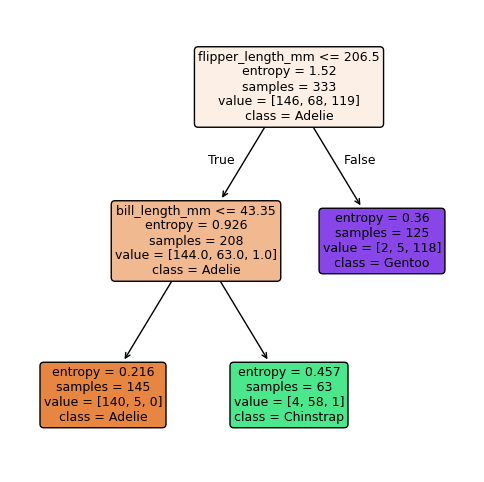

In [107]:
fig, ax = plt.subplots(figsize=(6, 6))
tree.plot_tree(ptree, feature_names=f_names,
                      class_names=species_names, fontsize = 9,
                      filled=True, rounded=True)
None # supressing the verbose return from plot_tree

In [108]:
tn = 15
for i,j in zip(X[tn],f_names):
    print(i,j)
y_pred = ptree.predict([X[tn]])
print('Prediced class label:',y_pred[0])

37.8 bill_length_mm
18.3 bill_depth_mm
174.0 flipper_length_mm
3400.0 body_mass_g
Prediced class label: Adelie


With pruning applied (min_samples_leaf=30,
                               min_impurity_decrease = 0.1), the decision tree achieves a **training accuracy of approximately 95%**, indicating good fit while avoiding overfitting

In [109]:
from sklearn.tree import DecisionTreeClassifier

ptree = DecisionTreeClassifier(
    criterion="entropy",
    min_samples_leaf=30,
    min_impurity_decrease=0.1,
    random_state=42
)

ptree.fit(X, y)

ptree.score(X, y)

0.948948948948949

When **no pruning** is enforced, the Penguins decision tree becomes very deep and bushy, achieving **perfect accuracy=1.0** on the training data, which indicates overfitting.

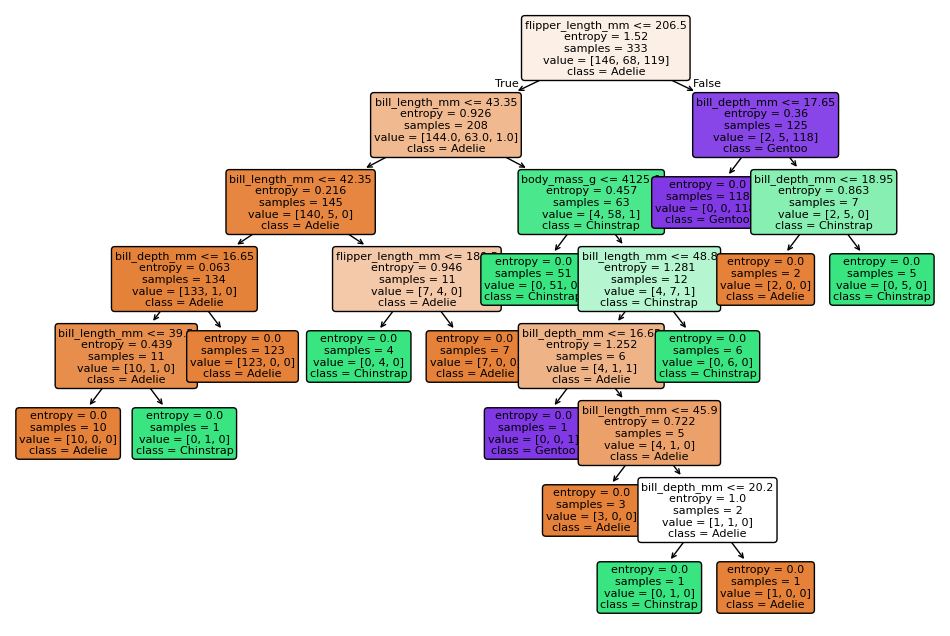

1.0

In [111]:
# Decision Tree WITHOUT pruning
full_tree = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

full_tree.fit(X, y)

# Visualise the tree
plt.figure(figsize=(12, 8))
tree.plot_tree(
    full_tree,
    feature_names=f_names,
    class_names=species_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

# Training accuracy
full_tree.score(X, y)

**4.2. DecisionTreeClassifier parameters to control tree complexity**

**max_depth** -
Limits the maximum depth of the tree, preventing it from growing too deep.

**min_samples_split** -
Specifies the minimum number of samples required to split an internal node.

**min_samples_leaf** -
Ensures that leaf nodes contain at least a minimum number of samples.

**max_leaf_nodes** -
Limits the total number of leaf nodes in the tree.

**min_weight_fraction_leaf** -
Sets the minimum fraction of the total sample weight required at a leaf node.

**min_impurity_decrease** -
Requires a minimum reduction in impurity for a split to be performed.

**max_features** -
Restricts the number of features considered when looking for the best split.

**splitter** -
Controls whether the best split or a random split is chosen at each node.

**criterion** -
Determines the impurity measure used to evaluate splits (e.g. gini or entropy).

**4.3. Tree with max_depth**
Limiting the maximum depth forces the tree to stop growing early (3 levels), resulting in a compact structure with fewer splits and training accuracy=**0.97.**

**Tree with max_leaf_nodes**
Restricting the number of leaf nodes (max_leaf_nodes=6) constrains the overall size of the tree, allowing only the most informative splits and producing a simpler, more interpretable model with the same **accurace = 0.96**.

Training score (max_depth=3): 0.96996996996997


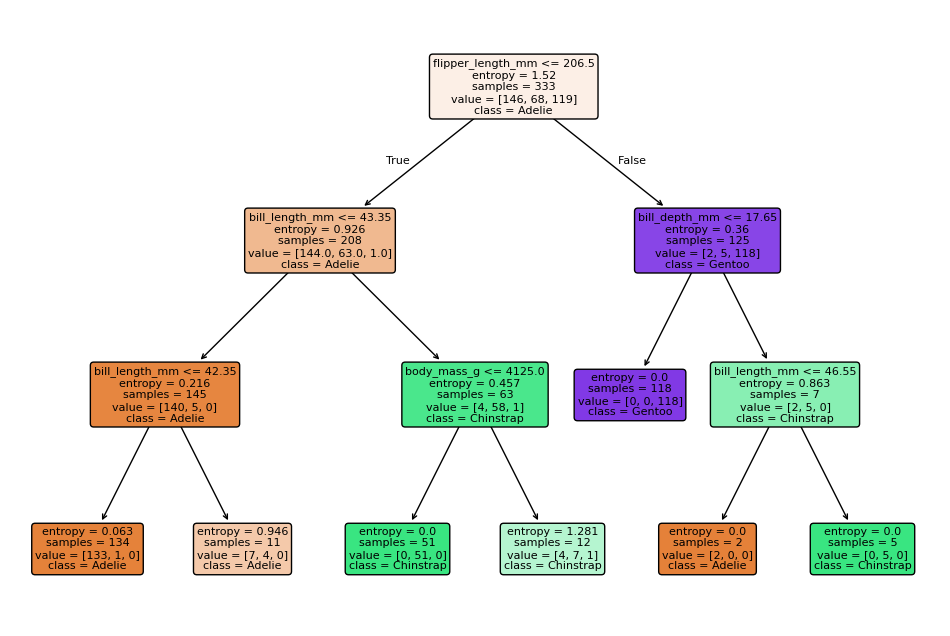

In [115]:
# Pruning with max_depth

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

t_depth = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

t_depth.fit(X, y)

print("Training score (max_depth=3):", t_depth.score(X, y))

plt.figure(figsize=(12, 8))
tree.plot_tree(
    t_depth,
    feature_names=f_names,
    class_names=species_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

Training score (max_leaf_nodes=6): 0.963963963963964


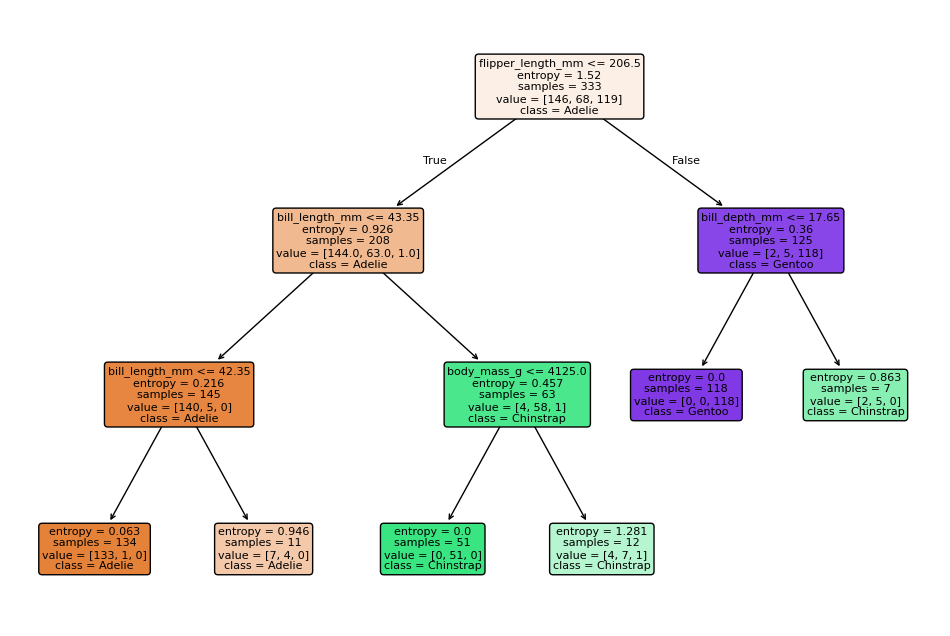

In [117]:
# Pruning with max_leaf_nodes

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

t_leaf = DecisionTreeClassifier(
    criterion="entropy",
    max_leaf_nodes=6,
    random_state=42
)

t_leaf.fit(X, y)

print("Training score (max_leaf_nodes=6):", t_leaf.score(X, y))

plt.figure(figsize=(12, 8))
tree.plot_tree(
    t_leaf,
    feature_names=f_names,
    class_names=species_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼◼